Task 1: 


A researcher wants to predict the life expectancy of countries based on socio-economic and health factors. You are tasked with building a Linear Regression model that can predict life expectancy using historical data.


Dataset: Use the “Life Expectancy (WHO)” dataset from Kaggle (or a similar dataset with numeric features for prediction).


Dataset features:
    o	Adult Mortality → mortality rate of adults (per 1000 population)
    o	Alcohol → alcohol consumption per capita (litres)
    o	GDP → Gross Domestic Product per capita
    o	Schooling → average years of schooling
    o	HIV/AIDS → prevalence rate (%)
    o	Life expectancy → target variable



1.	Load Data: Import CSV using pandas.

In [1]:
import pandas as pd

df = pd.read_csv("Life Expectancy Data.csv")

print(df.head())

       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population  \
0    6.

2.	Explore: Check missing values, basic stats (df.describe()), scatter plots.

2.1 Check Missing Values

In [2]:
print(df.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


2.2 Basic Statistics

In [3]:
print(df.describe())

              Year  Life expectancy   Adult Mortality  infant deaths  \
count  2938.000000       2928.000000      2928.000000    2938.000000   
mean   2007.518720         69.224932       164.796448      30.303948   
std       4.613841          9.523867       124.292079     117.926501   
min    2000.000000         36.300000         1.000000       0.000000   
25%    2004.000000         63.100000        74.000000       0.000000   
50%    2008.000000         72.100000       144.000000       3.000000   
75%    2012.000000         75.700000       228.000000      22.000000   
max    2015.000000         89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B       Measles   \
count  2744.000000             2938.000000  2385.000000    2938.000000   
mean      4.602861              738.251295    80.940461    2419.592240   
std       4.052413             1987.914858    25.070016   11467.272489   
min       0.010000                0.000000     1.000000

2.3 Visual Exploration (Scatter Plots)

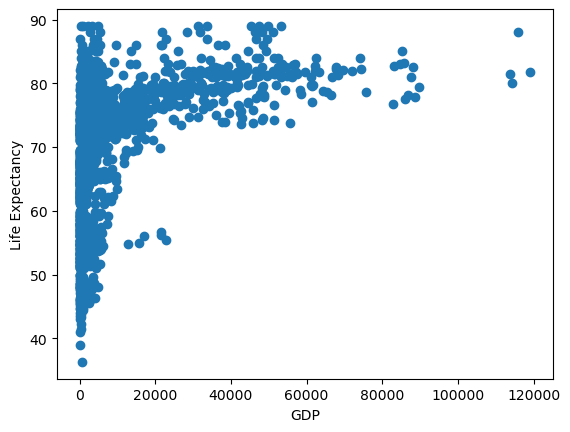

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df["GDP"], df["Life expectancy "])
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.show()

3 Data Preparation

3.1 Select Features & Target

In [5]:
features = ["Adult Mortality", "Alcohol", "GDP", "Schooling", " HIV/AIDS"]
X = df[features]
y = df["Life expectancy "]

3.2 Handle Missing Values

In [6]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())

3.3 Train-Test Split (80/20)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4 Build Linear Regression Model
LifeExpectancy=b0+b1X1+b2X2+...+bnXn

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

5 Evaluate Model

5.1 Predictions

In [9]:
y_pred = model.predict(X_test)

5.2 Mean Squared Error (MSE)

In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 20.735381733238214


5.3 R² Score

In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7606589085483255


6 Interpretation

6.1 Model Coefficients

In [12]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coefficients)

           Feature  Coefficient
0  Adult Mortality    -0.025286
1          Alcohol     0.163961
2              GDP     0.000066
3        Schooling     1.277675
4         HIV/AIDS    -0.502265


6.2 Plot Actual vs Predicted

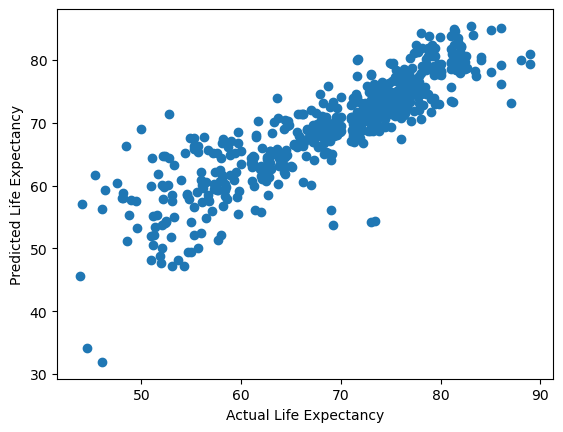

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.show()